In [38]:
%load_ext autoreload
%autoreload 2
%cd ../..

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home


In [39]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from tqdm import tqdm

warnings.filterwarnings("ignore")

from notebooks.utils import *

## Loading

In [3]:
FIG_PATH = "MolGenDocking-latex/Figures/Results/MolGen/Reinvent"
os.makedirs(FIG_PATH, exist_ok=True)

files = [f for d in MOLSTRAL_PATH.iterdir() for f in d.iterdir() if "" in str(f) and str(f).endswith("_scored.jsonl")]
# files = [Path("MolGenOutput/test_ood/RL-Mistral-24B-100/RL-Mistral-24B-100_0_scored.jsonl")]
files = sorted(files)[::-1]

print("Total files:", len(files))
save_df_path = Path("MolGenOutput/test_ood.csv")
if save_df_path.exists():
    df = pd.read_csv(save_df_path)
else:
    df = load_molgen_results(files[:])
    df.to_csv(save_df_path, index=False)

Total files: 129


In [4]:
df.head()

,prompt_id,reward,model,n_props,properties,objectives,smiles,validity,valid,Model
0,3837103906320391600,0.0,gpt-oss-120b,3,"sample_320341_model_0,SA,CalcPhi","minimize,below,maximize",CF₃,1,valid,gpt-oss
1,3837103906320391600,0.0,gpt-oss-120b,3,"sample_320341_model_0,SA,CalcPhi","minimize,below,maximize",NaN,0,multiple SMILES,gpt-oss
2,3837103906320391600,0.0,gpt-oss-120b,3,"sample_320341_model_0,SA,CalcPhi","minimize,below,maximize",NaN,0,no valid SMILES,gpt-oss
3,3837103906320391600,0.0,gpt-oss-120b,3,"sample_320341_model_0,SA,CalcPhi","minimize,below,maximize",NaN,0,multiple SMILES,gpt-oss
4,3837103906320391600,0.0,gpt-oss-120b,3,"sample_320341_model_0,SA,CalcPhi","minimize,below,maximize",NaN,0,no answer,gpt-oss


In [5]:
df_reinvent = pd.read_csv("MolGenOutput/reinvent/std_params-res.csv")
df_reinvent["Model"] = "Reinvent-STD"
df_reinvent["validity"] = df_reinvent["smiles"].apply(lambda x: 1 if isinstance(x, str) and Chem.MolFromSmiles(x) is not None else 0)
df_reinvent = df_reinvent.drop(columns=["target"])
df_reinvent.columns

Index(['model', 'prompt_id', 'smiles', 'properties', 'objectives', 'reward',
       'Model', 'validity'],
      dtype='str')

In [6]:
df = pd.concat([df[df_reinvent.columns.tolist()], df_reinvent], ignore_index=True).reset_index(drop=True)

In [7]:
sub_sample_prompts = df[df.Model == "Reinvent-STD"].prompt_id.unique()[:]
df = df[df.prompt_id.isin(sub_sample_prompts)]


sub_sample_prompts = df[df.Model == "gemma-4"].prompt_id.unique()[:]
df = df[df.prompt_id.isin(sub_sample_prompts)]

sub_sample_prompts = df[df.Model == "RL-Molstral-g4"].prompt_id.unique()[:]
df = df[df.prompt_id.isin(sub_sample_prompts)]

sub_sample_prompts = df[df.Model == "Mistral-Small-4"].prompt_id.unique()[:]
df = df[df.prompt_id.isin(sub_sample_prompts)]


In [8]:
df.groupby(["Model", "prompt_id"]).validity.count().reset_index().groupby("Model").validity.sum()

Model
ChemDFM-R          7424
ChemDFM-v2.0       7424
Llama-3.3          7424
MiniMax-M2         7424
Mistral-Small-4    7424
Qwen3              7424
Qwen3-Next         7424
R1-Llama           7424
R1-Qwen            7424
RL-Mistral         7424
RL-Molstral-g16    3712
RL-Molstral-g4     3712
RL-Molstral-g8     3712
Reinvent-STD       3712
ZINC               7424
ether0             7424
gemma-3            7424
gemma-4            7424
gpt-oss            7424
Name: validity, dtype: int64

In [9]:
min_vals = df.groupby(["Model", "prompt_id"]).reward.count().reset_index().groupby("Model").reward.min().min()

df = df.groupby(["Model", "prompt_id"]).sample(min_vals, random_state=42).reset_index()
df

,index,model,prompt_id,smiles,properties,objectives,reward,Model,validity
0,2087142,ChemDFM-R-14B,109010,CCCCCCCCN(CCCCCCCC)c1ccccc1OP(=O)(O)Oc1ccccc1N...,sample_753036_model_0,minimize,0.00000,ChemDFM-R,1
1,2087127,ChemDFM-R-14B,109010,CC(O)CNC(=O)c1ccccc1,sample_753036_model_0,minimize,0.46775,ChemDFM-R,1
2,2087106,ChemDFM-R-14B,109010,NC(Cc1ccccc1)C(=O)N[C@@H](CC(N)=O)C(=O)O,sample_753036_model_0,minimize,0.63600,ChemDFM-R,1
3,2087118,ChemDFM-R-14B,109010,O=C(NC1CCN(Cc2ccc(F)cc2)CC1)c1cnc2c(c1)N=C(c1c...,sample_753036_model_0,minimize,0.00000,ChemDFM-R,1
4,2087185,ChemDFM-R-14B,109010,NC(=O)Cc1cccc2c(=O)c(C(=O)O)cn(C3CC3)c12,sample_753036_model_0,minimize,0.82850,ChemDFM-R,1
...,...,...,...,...,...,...,...,...,...
70523,122515,gpt-oss-120b,8893-105,NaN,5en4_5Q6_A_302,below,0.00000,gpt-oss,0
70524,122609,gpt-oss-120b,8893-105,CC(C)C1=NC2=CC=CC=C2N=C1NCC(=O)NCCO,5en4_5Q6_A_302,below,0.00000,gpt-oss,1
70525,122550,gpt-oss-120b,8893-105,c1cc(ccc1C(=O)NCC2=NC3=CC=CC=C3N=C2)S(=O)(=O)N,5en4_5Q6_A_302,below,0.00000,gpt-oss,1
70526,122516,gpt-oss-120b,8893-105,O=C(N[C@@H]([C@H]([C@@H]([C@H]([C@@H](O)CO)O)O...,5en4_5Q6_A_302,below,0.00000,gpt-oss,1


In [10]:
min_vals

64

# Uniqueness and Diversity Metrics

In [11]:
import re
valid_smiles_pattern = re.compile(r"^[A-Za-z0-9=#:\+\-\[\]\(\)/\\@.%]+$")
mkd_pattern = re.compile(r"^(\*\*|[-*'])(.+)\1$")
def get_mol(smi):
    if not isinstance(smi, str):
        return None
    smi = smi.strip()
    m = mkd_pattern.match(smi)
    x = m.group(2) if m else smi
    return Chem.MolFromSmiles(x)

df["Mol"] = df["smiles"].progress_apply(get_mol)
df["CanSMI"] = df["Mol"].progress_apply(lambda x: None if x is None else Chem.MolToSmiles(x))


100%|██████████| 70528/70528 [00:05<00:00, 12414.72it/s]


## Computations

Compute the uniqueness of the generated smiles in each prompt

In [12]:
uniq_df = df[df.validity == 1].groupby(["Model", "prompt_id"]).agg(
    **{f"{k}":pd.NamedAgg(column="CanSMI", aggfunc=aggregate_molgen_fn("uniqueness", k)) for k in list(range(1,100,10))}
).reset_index()
uniq_df = uniq_df.melt(id_vars=["Model"], value_vars=[str(k) for k in list(range(1,100,10))], var_name="n_rollout")
uniq_df["n_rollout"] = uniq_df["n_rollout"].apply(int)

Diversity in each prompt (ecfp4)

In [13]:
fp_fn = fp_name_to_fn("ecfp4-2048")

sub_df = df[df.Mol.apply(lambda x: x is not None)].drop_duplicates(subset=["prompt_id", "CanSMI"])
sub_df["fps"] = sub_df["Mol"].progress_apply(fp_fn)

sim_df = sub_df.groupby(["Model", "prompt_id"]).agg(
    **{
        f"{k}":pd.NamedAgg(
            column="fps",
            aggfunc=aggregate_molgen_fn("diversity",k, is_fp=True))
        for k in [50]
    }
).reset_index()
sim_df = sim_df.melt(id_vars=["Model"], value_vars=[str(k) for k in [50]], var_name="n_rollout")
sim_df["n_rollout"] = sim_df["n_rollout"].apply(int)

100%|██████████| 47365/47365 [00:03<00:00, 13846.68it/s]


## Plots

In [27]:
uniq_df = uniq_df[uniq_df.Model != "ZINC"]
uniq_df["Proportion of duplicates"] = 1- uniq_df["value"]

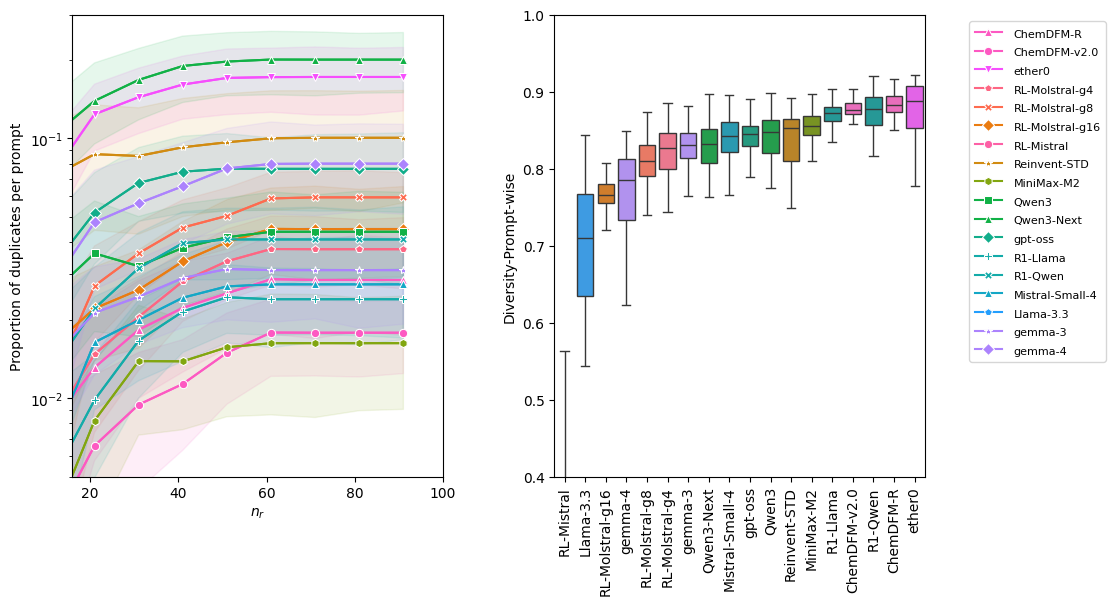

In [28]:
from notebooks.utils import CMAP_MODELS, MARKER_MODELS

fig, axes = plt.subplots(1, 2, figsize=(11,6), sharey=False, gridspec_kw={"wspace":0.3})

ax = axes[0]
sns.lineplot(uniq_df, x="n_rollout", y="Proportion of duplicates", hue="Model", ax=ax, legend=False, palette=CMAP_MODELS, hue_order=CMAP_MODELS.keys(), err_kws={"alpha":0.1})
sns.lineplot(uniq_df[uniq_df.n_rollout % 10 == 1], x="n_rollout", y="Proportion of duplicates", hue="Model", ax=ax, legend=True, palette=CMAP_MODELS, hue_order=CMAP_MODELS.keys(), errorbar=None, style="Model", dashes=False, markers = MARKER_MODELS)

ax.set_ylabel("Proportion of duplicates per prompt")
ax.set_xlabel("$n_r$")
ax.set_ylim(0.005,0.3)
ax.set_xlim(16,100)
ax.set_yscale("log")
# Move legend below plot
legend = ax.legend(bbox_to_anchor=(2.4, 1.0), loc='upper left', ncols=1)
# Make legend smaller
for text in legend.get_texts():
    text.set_fontsize(8)

ax = axes[1]
x_order = sim_df[sim_df.Model != "ZINC"].groupby("Model")["value"].median().sort_values().index.tolist()
sns.boxplot(sim_df[sim_df.Model != "ZINC"], x="Model", y="value", hue="Model", ax=ax, legend = False, order=x_order, palette=CMAP_MODELS,fliersize=0)
ax.set_ylabel("Diversity-Prompt-wise")
ax.set_xlabel("")
# rotate x ticks
ax.set(ylim=(0.4,1))
# ax.set_yscale("log")
ax.tick_params(axis='x', rotation=90)

fig.savefig(f"{FIG_PATH}/uniqueness_diversity.pdf", bbox_inches='tight')

# Tables for Top-k

In [16]:
from notebooks.metadata.molgen import MODEL_META
from notebooks.utils import aggregate_molgen_fn
LATEX_PATH = "MolGenDocking-latex/tables/results"

MODEL_META["reinvent"]= {
     "size": "0.2B",
    "thinking": False,
    "Chem.": True,
}

MODEL_ORDER = [
    "reinvent", #
    "gemma-4", #04/26
    "Mistral-Small-4", #03/26
    "MiniMax-M2",# 10/25
    # "Qwen3-Next",# 09/25
    # "gpt-oss",# 08/25
    # "Qwen3", # 04/24
    # "Llama-3.3",#04/25
    # "gemma-3",#03/25
    # "R1-Llama",#01/25
    # "R1-Qwen",#01/25
    # "ether0",
    "ChemDFM-R",
    # "ChemDFM-v2.0",
    # "RL-Molstral-g4",
    # "RL-Molstral-g8",
    "RL-Molstral-g16",
    # "RL-Mistral",
]

In [17]:
# Create table with: model_name, size, metric_name, value
import re

Ks = [1, 16]
N_r = [16, 24, 32, 48]

N_reperform = 5

table = []
size_pattern = re.compile(r'(?i)(?:^|[-_])(\d+\s*[b])(?:$|[-_])')
pbar = tqdm(total=len(df.model.unique())*len(N_r) * len(Ks) * N_reperform)
df.model = df.model.apply(lambda x: "Mistral-Small-4-128B" if  x == "Mistral-Small-128B" else x)

for model_name in df.model.unique():
    assert any([m in model_name for m in MODEL_META.keys()]), f"Model {model_name} not found in MODEL_META"
    key = [m for m in MODEL_META.keys() if m in model_name][0]
    metadata = MODEL_META[key]
    for k in Ks:
        for n_rollout in N_r:
            for _ in range(N_reperform):
                sub_df = df[df.model == model_name]
                # sub_df = sub_df.drop_duplicates(subset=["prompt_id", "smiles"])
                pass_k = sub_df.groupby("prompt_id").apply(
                    aggregate_molgen_fn("topk",k=k, n_rollout=n_rollout)
                ).to_frame().rename(columns={0:str(k)}).reset_index()
                if not "size" in metadata:
                    try:
                        size = size_pattern.search(model_name).group(1).upper()
                    except:
                        raise ValueError(f"Size not found for model {model_name}")
                else:
                    size = metadata["size"]
                for i, row in pass_k.iterrows():

                    table.append(
                        [
                            model_name,
                            size,
                            f"$n_r=${n_rollout}",
                            k,
                            row[str(k)],
                            row["prompt_id"]
                        ]
                    )
                pbar.update(1)
table= pd.DataFrame(columns=["model", "Size", "Metric", "k", "Value", "prompt_id"], data=table)

100%|██████████| 760/760 [02:02<00:00,  6.04it/s]

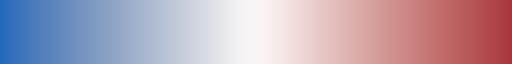

In [18]:
from notebooks.utils.utils import process_model_name

table["K"] = table["k"].apply(lambda x: r"$\text{top}_{" + str(x) + "}$")
table["Model"] = table["model"].apply(process_model_name)
table[r"Size (B)"] = table["Size"].apply(lambda x: str(x).replace("B", ""))

cmap = sns.color_palette("vlag", as_cmap=True)
cmap

In [19]:
def post_process_latex(
    latex: str,
    sep_del=[
        "reinvent"
    ],
    sep=[
        # r"\multicolumn{" + str(len(N_r)*len(Ks) + 2) + r"}{c}{Random Sampling on ZINC} \\",
        r"\midrule"

    ]
):
    latex_lines = latex.split("\n")
    new_latex = latex_lines[:3]

    last_header = "&".join(latex_lines[4].split("&")[:2]) + "&" + "&".join(latex_lines[3].split("&")[2:])
    new_latex.append(last_header)
    i_sp = 0
    for line in latex_lines[5:]:
        if r"\midrule" in line:
            continue
        if i_sp < len(sep) and sep_del[i_sp] in line:
            new_latex += [sep[i_sp]]
            i_sp += 1
        new_latex.append(line)
    return "\n".join(new_latex)

In [20]:
table = table[table.Model.isin(MODEL_ORDER)]

In [21]:
from notebooks.utils import PandasTableFormatter

def color_map(val: float) -> str:
    "Returns a color based on the value (eg '#FF5733')"
    val = 1/(1+np.exp(-3*(val -0.6)))
    color = cmap(val)
    return f"rgb({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)})"

formatter = PandasTableFormatter(
    n_decimals = 2, # Number of decimals to keep in the table
    aggregation_methods=["mean", "std"], # Aggregation functions to apply to the data
    main_subset=0, # Subset of values to bold, here the first column will be bolded corresponding to the mean values, if [0,1] the first two columns will be bolded (independently)
    hide_agg_labels=True, # Hide the aggregation column names in the latex
    global_agg=False, # Whether to compute global aggregation across all columns (True)
    color_mapping =color_map,
    groupby_col="prompt_id",
    color_mapping_key_idx=0,
    merge_aggs=True
)

style = formatter.style(
    table, # Dataframe to format
    rows= ["Model", r"Size"], # Rows
    cols=["Metric", r"K"], # Columns
    values= "Value", # Values
    highlight_fn= np.nanmax, # Function to use to highlight the values, here the maximum values will be highlighted
    props=["textbf:--rwrap--latex; underline:--rwrap--latex", "underline:--rwrap--latex"], # Properties to apply to the highlighted values, here the maximum values will be underlined and bolded, the second maximum values will be bolded
    special_format_agg = {
        "std": lambda x: "\\tiny $\\pm$" + x, # Format to apply to the standard deviation values
    },
    remove_col_names=True,
    row_order = MODEL_ORDER
)
latex = post_process_latex(
    formatter.latex(
        style, None, multicol_align="c||", hrules=True, column_format="c|c||" + "".join(["p{1.3cm}" * len(Ks) + "||" for _  in range(len(N_r))])
    )
)

with open(f"{LATEX_PATH}/gen_table_reinvent.tex", "w") as f:
    f.write(latex)


style

In [22]:
latex

'\\begin{tabular}{c|c||p{1.3cm}p{1.3cm}||p{1.3cm}p{1.3cm}||p{1.3cm}p{1.3cm}||p{1.3cm}p{1.3cm}||}\n\\toprule\n &  & \\multicolumn{2}{c||}{$n_r=$16} & \\multicolumn{2}{c||}{$n_r=$24} & \\multicolumn{2}{c||}{$n_r=$32} & \\multicolumn{2}{c||}{$n_r=$48} \\\\\nModel & Size & $\\text{top}_{1}$ & $\\text{top}_{16}$ & $\\text{top}_{1}$ & $\\text{top}_{16}$ & $\\text{top}_{1}$ & $\\text{top}_{16}$ & $\\text{top}_{1}$ & $\\text{top}_{16}$ \\\\\n\\midrule\nreinvent & 0.2B & \\textbf{\\underline{{\\cellcolor[rgb]{0.906, 0.784, 0.776}} 0.78 \\tiny $\\pm$0.03}} & \\textbf{\\underline{{\\cellcolor[rgb]{0.929, 0.925, 0.937}} 0.53 \\tiny $\\pm$0.04}} & \\textbf{\\underline{{\\cellcolor[rgb]{0.902, 0.776, 0.769}} 0.78 \\tiny $\\pm$0.01}} & \\textbf{\\underline{{\\cellcolor[rgb]{0.980, 0.945, 0.941}} 0.63 \\tiny $\\pm$0.03}} & \\textbf{\\underline{{\\cellcolor[rgb]{0.898, 0.765, 0.757}} 0.79 \\tiny $\\pm$0.02}} & \\textbf{\\underline{{\\cellcolor[rgb]{0.969, 0.922, 0.914}} 0.66 \\tiny $\\pm$0.02}} & \\tex

# DIVTOPK plot

In [23]:
from notebooks.results.DivTopK import run_figure, load_config

In [34]:
df["smiles"] = df.apply(lambda row: row.smiles if row.validity else "", axis = 1)
df["smiles"] = df["smiles"].fillna("")


Computing fingerprints:   0%|          | 0/22272 [00:00<?, ?it/s][16:33:18] DEPRECATION WARNING: please use MorganGenerator

Computing fingerprints:   0%|          | 16/22272 [00:01<31:39, 11.72it/s][16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: please use MorganGenerator
[16:33:18] DEPRECATION WARNING: p

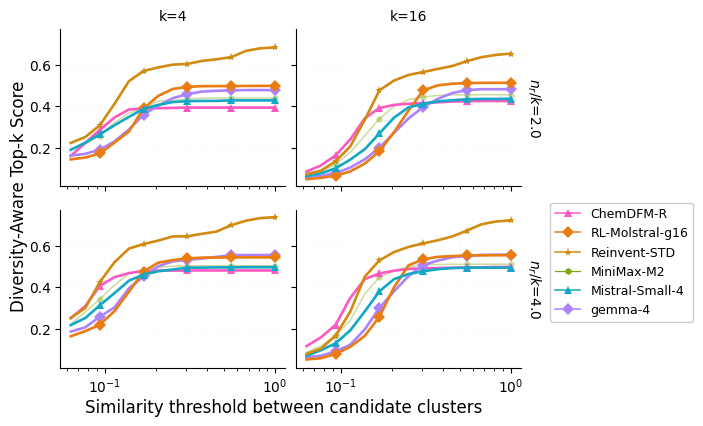

Saved: MolGenDocking-latex/Figures/Results/MolGen/diversity_rewards-reinvent/ecfp6-2048-main.pdf


In [35]:
config = load_config("notebooks/results/configs/main_figure.yaml")
config["highlight_model"] = df.Model.unique()
config["paths"]["output_subdir"] = "diversity_rewards-reinvent"

run_figure(
    config = config,
    display=True,
    df=df[
        df.Model.isin(
            [
                'ChemDFM-R',
                'MiniMax-M2',
                'Mistral-Small-4',
                'RL-Molstral-g16',
                'Reinvent-STD',
                'gemma-4',
            ]
        )
    ]
)

In [33]:
df.smiles.isna().any()

True